# **Курсовая работа по теме «Машинное обучение в задачах предсказания оттока клиентов»**
Студента группы ПМ23-1\
Факультета информационных технологий и анализа больших данных\
Грошева А.А.

Научный руководитель\
Шин В.И.

Цель работы - на основе имеющегося датасета о клиентах сотовой компании построить разные модели предсказания и сделать вывод о наилучших.

Задачи работы:
1. Выполнить описательный анализ данных и сделать вывод о дальнейшем построении моделей
2. Построить 7 разных моделей классификации
3. Сравнить модели

In [1]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, learning_curve, KFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay, recall_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB

# Данные

In [2]:
data = pd.read_csv("C:/Users/Arkadiy/Desktop/telecom_churn.csv")

In [3]:
data.head()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,128,1,1,2.7,1,265.1,110,89.0,9.87,10.0
1,0,107,1,1,3.7,1,161.6,123,82.0,9.78,13.7
2,0,137,1,0,0.0,0,243.4,114,52.0,6.06,12.2
3,0,84,0,0,0.0,2,299.4,71,57.0,3.10,6.6
4,0,75,0,0,0.0,3,166.7,113,41.0,7.42,10.1


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Churn            3333 non-null   int64  
 1   AccountWeeks     3333 non-null   int64  
 2   ContractRenewal  3333 non-null   int64  
 3   DataPlan         3333 non-null   int64  
 4   DataUsage        3333 non-null   float64
 5   CustServCalls    3333 non-null   int64  
 6   DayMins          3333 non-null   float64
 7   DayCalls         3333 non-null   int64  
 8   MonthlyCharge    3333 non-null   float64
 9   OverageFee       3333 non-null   float64
 10  RoamMins         3333 non-null   float64
dtypes: float64(5), int64(6)
memory usage: 286.6 KB


In [5]:
data.isna().sum()

Churn              0
AccountWeeks       0
ContractRenewal    0
DataPlan           0
DataUsage          0
CustServCalls      0
DayMins            0
DayCalls           0
MonthlyCharge      0
OverageFee         0
RoamMins           0
dtype: int64

Пропущенных значений нет

In [6]:
X = data.iloc[:, 1:]
y = data['Churn']

# Описательный анализ

Посчитаем долю ушедших клиентов

In [7]:
print("Доля ушедших клиентов:", len(np.where(y == 1)[0]) / len(data))

Доля ушедших клиентов: 0.14491449144914492


Выведем корреляционную матрицу

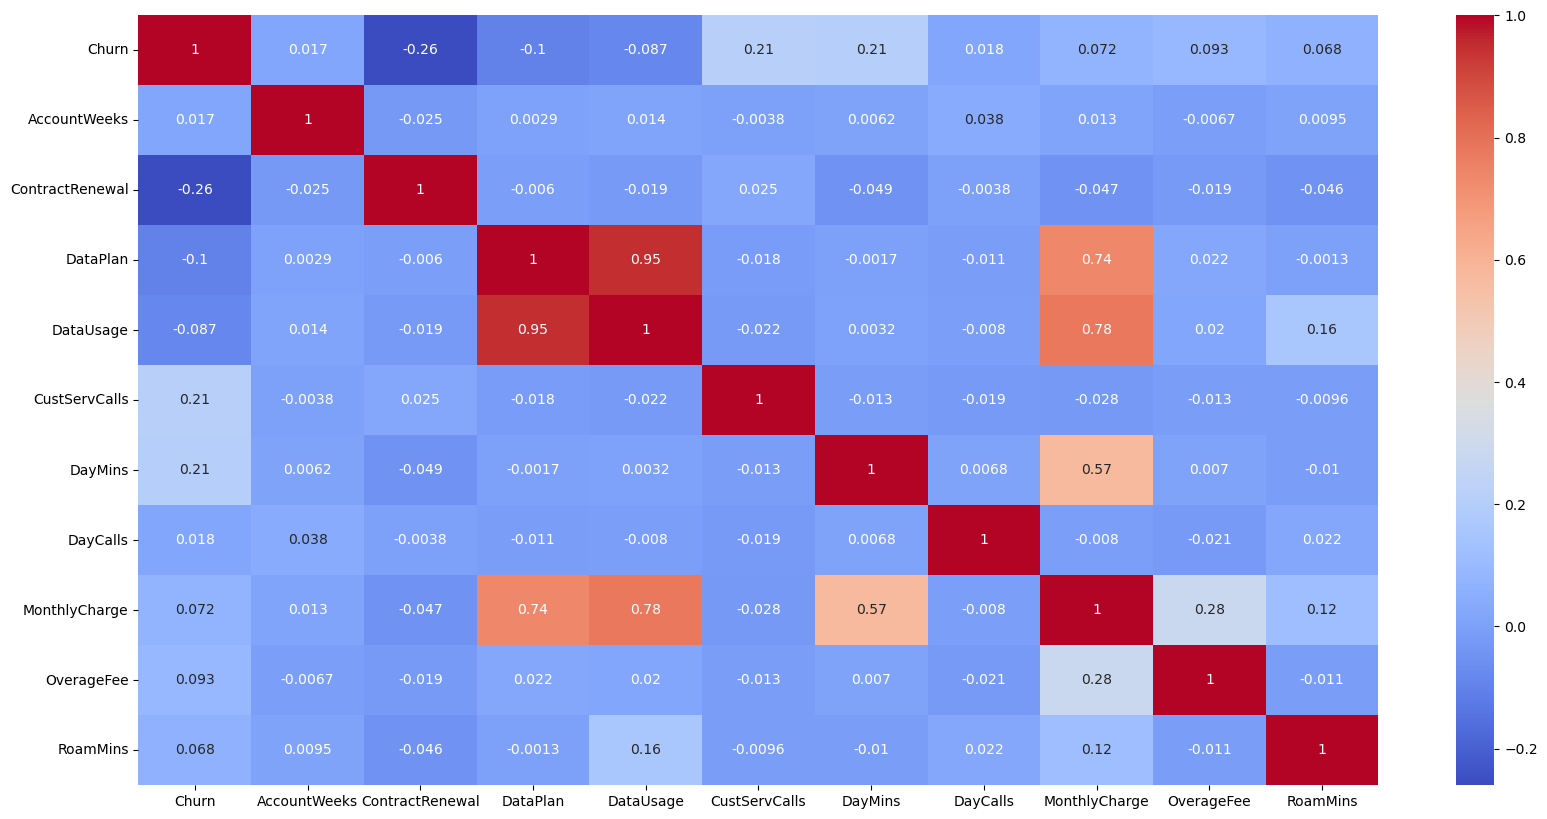

In [8]:
plt.figure(figsize=(20, 10))
sns.heatmap(data.corr(), annot = True, cmap = 'coolwarm')
plt.show()

Заметим, что признаки AccountWeeks и DayCalls почти не влияют на целевую переменную. Не будем их использовать.

Распределение непрерывных числовых признаков

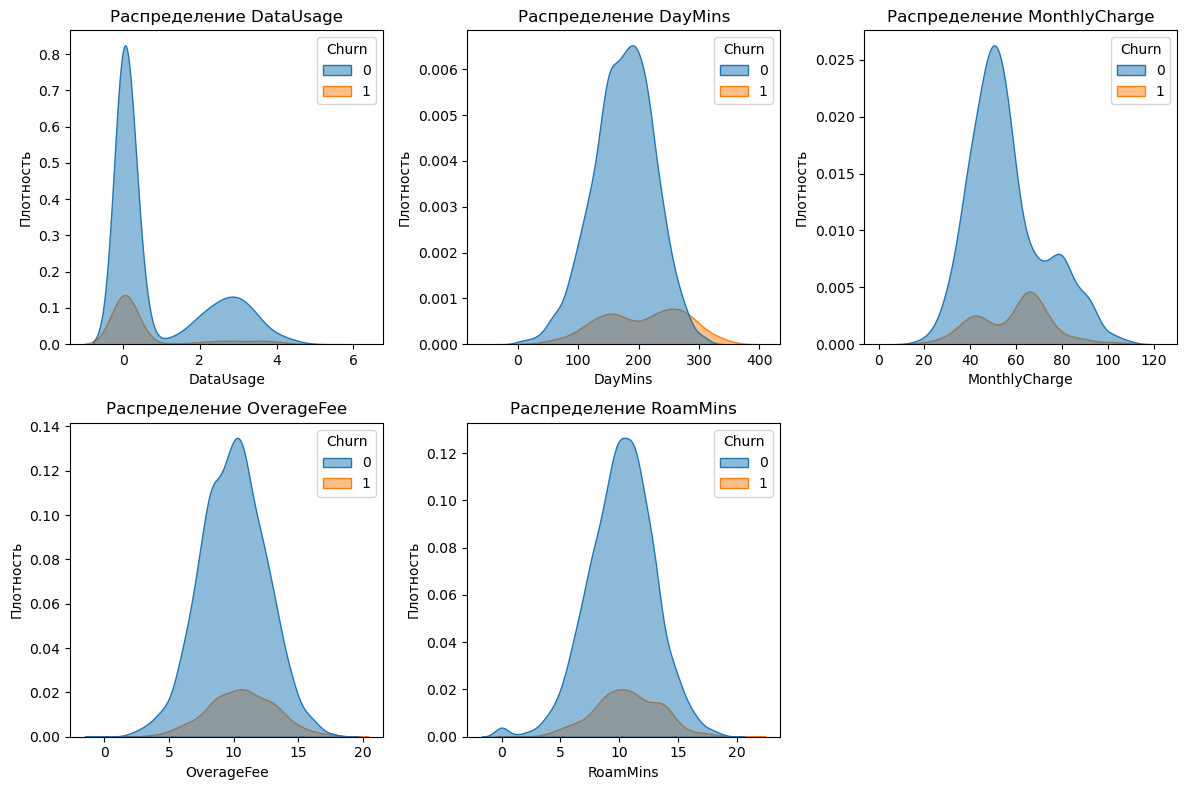

In [9]:
numerical_features = [
    "DataUsage",
    "DayMins",
    "MonthlyCharge",
    "OverageFee",
    "RoamMins"
]
plt.figure(figsize=(12, 8))
for i, feature in enumerate(numerical_features, 1):
    plt.subplot(2, 3, i)
    sns.kdeplot(data=data, x=feature, hue='Churn', fill=True, alpha=0.5)
    plt.title(f'Распределение {feature}')
    plt.xlabel(feature)
    plt.ylabel('Плотность')
plt.tight_layout()
plt.show()

Распределения категориальных признаков и количества звонков в поддержку

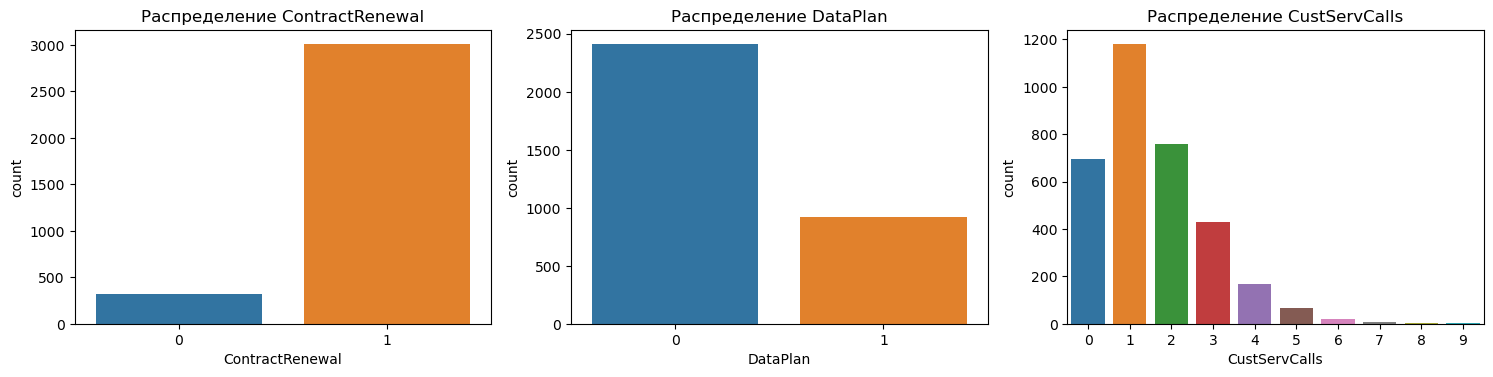

In [10]:
categorical_features = ['ContractRenewal', 'DataPlan', 'CustServCalls']
plt.figure(figsize=(20, 14))
for i, feature in enumerate(categorical_features, 1):
    plt.subplot(4, 4, i)
    sns.countplot(data=data, x=feature)
    plt.title(f'Распределение {feature}')
    plt.xticks(ticks = data[feature].unique())
plt.tight_layout()
plt.show()

# Построение моделей

Построим следующие модели:
1. KNN
2. Логистическая регрессия
3. SVM
4. Random Forest
5. Градиентный бустинг
6. Деревья решений
7. Наивный Байес

Будем использовать метрику accuracy, так как нам важна точность в целом. Также будем смотреть на recall, так как он показывает, насколько хорошо модель минимизирует ложно отрицательные предсказания, что может быть полезно в предсказании оттока клиентов.

In [11]:
data = data[["Churn","DayMins", "MonthlyCharge", "OverageFee", "DataPlan", "CustServCalls", "DataUsage", "ContractRenewal"]]
X = data.drop(columns=["Churn"])
y = data["Churn"]

In [12]:
# Разделим на train- и test выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [13]:
# Нормализуем значения
X_train = MinMaxScaler().fit_transform(X_train)
X_test = MinMaxScaler().fit_transform(X_test)

### KNN

Построим модель KNN\
Ниже представлен график зависимости точности от числа соседей

In [14]:
train_accuracies = {}
test_accuracies = {}
for neighbor in np.arange(1, 30, 2):
    knn = KNeighborsClassifier(n_neighbors=neighbor)
    knn.fit(X_train, y_train)
    train_accuracies[neighbor] = knn.score(X_train, y_train)
    test_accuracies[neighbor] = knn.score(X_test, y_test)

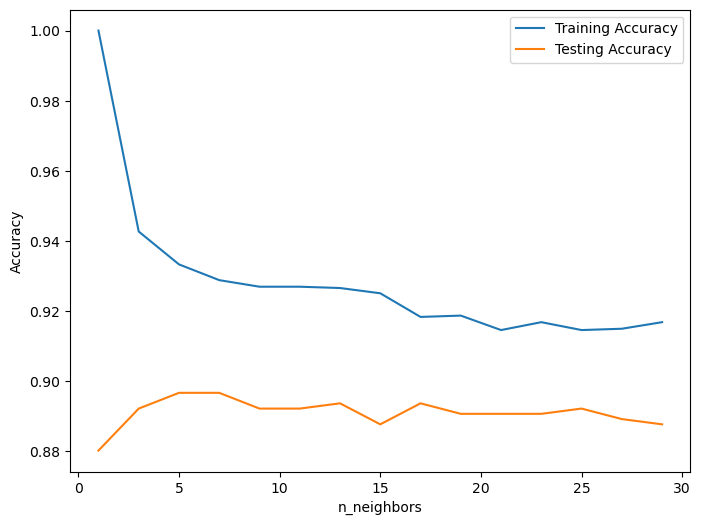

In [15]:
plt.figure(figsize=(8, 6))
plt.plot(np.arange(1, 30, 2), train_accuracies.values(), label="Training Accuracy")
plt.plot(np.arange(1, 30, 2), test_accuracies.values(), label="Testing Accuracy")
plt.legend()
plt.xlabel("n_neighbors")
plt.ylabel("Accuracy")
plt.show()

С помощью GridSearch найдем оптимальное значение n

In [16]:
knn = KNeighborsClassifier()
param_grid = {'n_neighbors': np.arange(1, 20, 1)}
grid_search = GridSearchCV(knn, param_grid, cv=5, return_train_score=True)
grid_search.fit(X_train, y_train)

print("Лучший параметр:", grid_search.best_params_)
print("Лучшая точность:", grid_search.best_score_)

Лучший параметр: {'n_neighbors': 9}
Лучшая точность: 0.914483068771915


In [17]:
best_knn = grid_search.best_estimator_
test_accuracy = best_knn.score(X_test, y_test)
print(f"Точность на тестовом наборе: {test_accuracy:.4f}")

Точность на тестовом наборе: 0.8921


Построим также кривые обучения

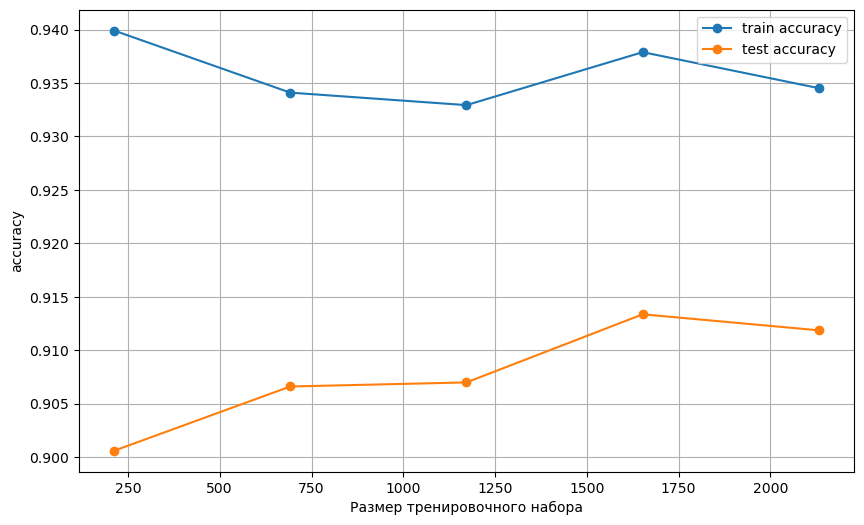

In [18]:
def plot_learning_curve(model, X, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 5)):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=cv, scoring='accuracy', train_sizes=train_sizes
    )
    
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label='train accuracy')
    plt.plot(train_sizes, np.mean(val_scores, axis=1), 'o-', label='test accuracy')
    plt.xlabel('Размер тренировочного набора')
    plt.ylabel('accuracy')
    plt.legend()
    plt.grid()
    plt.show()

plot_learning_curve(knn, X_train, y_train, cv=5)

Выведем отчет по разным метрикам

In [19]:
best_knn = KNeighborsClassifier(n_neighbors=9)
best_knn.fit(X_train, y_train)
y_pred_knn = best_knn.predict(X_test)
best_knn.score(X_test, y_test)
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.91      0.97      0.94       570
           1       0.70      0.45      0.55        97

    accuracy                           0.89       667
   macro avg       0.81      0.71      0.74       667
weighted avg       0.88      0.89      0.88       667



In [20]:
recall_score(y_test, best_knn.predict(X_test))

0.4536082474226804

Как видим, модель имеет достаточно высокую точность, однако относительно низкий recall, то есть допускает много ложно-отрицательных предсказаний, что не очень хорошо в нашем случае.

### Логистическая регрессия

In [39]:
model = LogisticRegression(solver='liblinear', max_iter=10000)

param_grid = {
    "C": np.linspace(0.01, 100, 10),
    "penalty": ["l1", "l2"],
}

grid_search = GridSearchCV(model, param_grid, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), scoring='accuracy')
grid_search.fit(X_train, y_train)

print("Лучшие параметры:", grid_search.best_params_)
print("Лучшая точность:", grid_search.best_score_)

Лучшие параметры: {'C': 33.339999999999996, 'penalty': 'l1'}
Лучшая точность: 0.8555909241028452


Кривые обучения

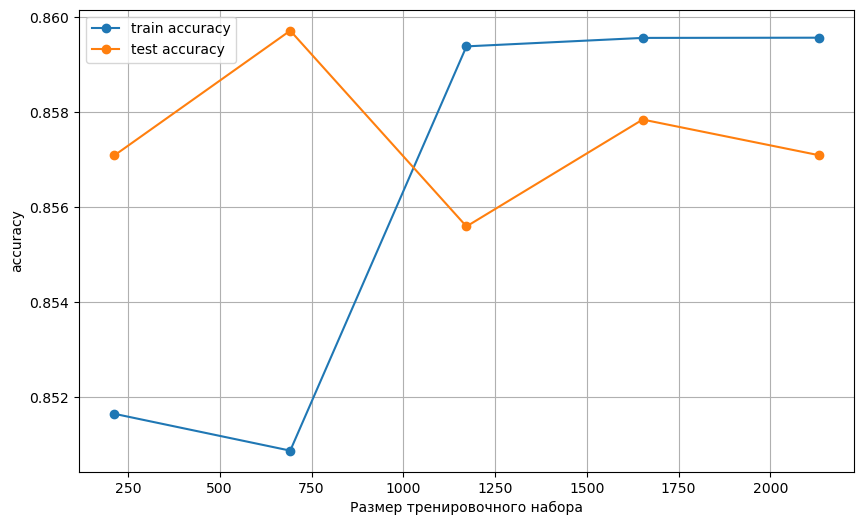

In [40]:
plot_learning_curve(model, X_train, y_train, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42))

Отчет по разным метрикам

In [41]:
best_search = grid_search.best_estimator_
print(classification_report(y_test, best_search.predict(X_test)))

              precision    recall  f1-score   support

           0       0.87      0.98      0.92       570
           1       0.55      0.18      0.27        97

    accuracy                           0.86       667
   macro avg       0.71      0.58      0.59       667
weighted avg       0.83      0.86      0.83       667



In [42]:
recall_score(y_test, best_search.predict(X_test))

0.17525773195876287

Тоже довольно хорошая точность, но очень низкий recall = 0.18

### SVM

In [43]:
params_svc = {
    "kernel": ["rbf", "poly"],
    "degree": [1, 2],
    "random_state": [22],
    "C": np.linspace(0.01, 100, 10),
}

svc = SVC()
grid_search = GridSearchCV(svc, params_svc, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), scoring='accuracy')
grid_search.fit(X_train, y_train)

print("Лучшие параметры:", grid_search.best_params_)
print("Лучшая точность:", grid_search.best_score_)

Лучшие параметры: {'C': 100.0, 'degree': 1, 'kernel': 'rbf', 'random_state': 22}
Лучшая точность: 0.9201059651045949


Кривые обучения

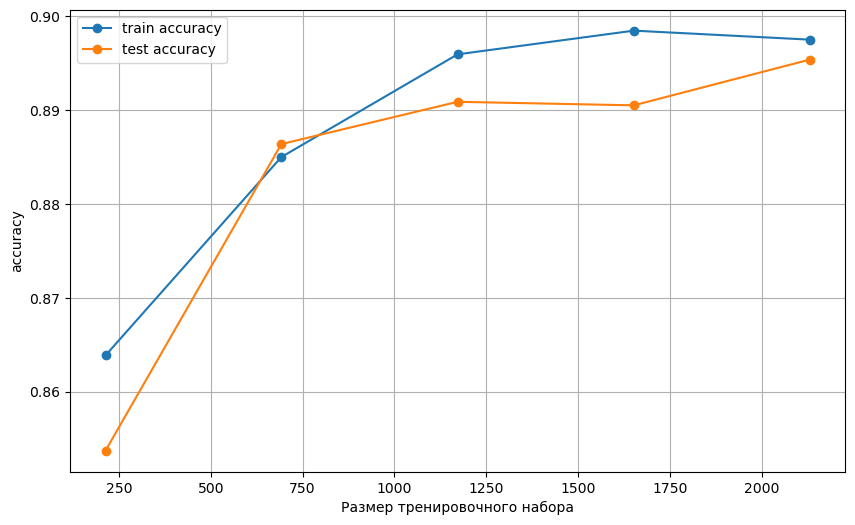

In [44]:
plot_learning_curve(svc, X_train, y_train, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42))

In [45]:
best_search = grid_search.best_estimator_
print(classification_report(y_test, best_search.predict(X_test)))

              precision    recall  f1-score   support

           0       0.92      0.97      0.95       570
           1       0.76      0.54      0.63        97

    accuracy                           0.91       667
   macro avg       0.84      0.75      0.79       667
weighted avg       0.90      0.91      0.90       667



Хорошая точность 0.91, recall = 0.54

### Random forest

In [28]:
params_rf = {
    "random_state": [42],
    "max_depth": [5, 10, 15],
    "min_samples_leaf": np.arange(0.01, 0.03, 0.01),
    "n_estimators": [100, 300, 500]
}
rf = RandomForestClassifier()
grid_search = GridSearchCV(rf, params_rf, cv=KFold(n_splits=5, shuffle=True, random_state=42), scoring='accuracy')
grid_search.fit(X_train, y_train)

print("Лучшие параметры:", grid_search.best_params_)
print("Лучшая точность:", grid_search.best_score_)

Лучшие параметры: {'max_depth': 10, 'min_samples_leaf': 0.01, 'n_estimators': 300, 'random_state': 42}
Лучшая точность: 0.9186022162728109


Кривые обучения

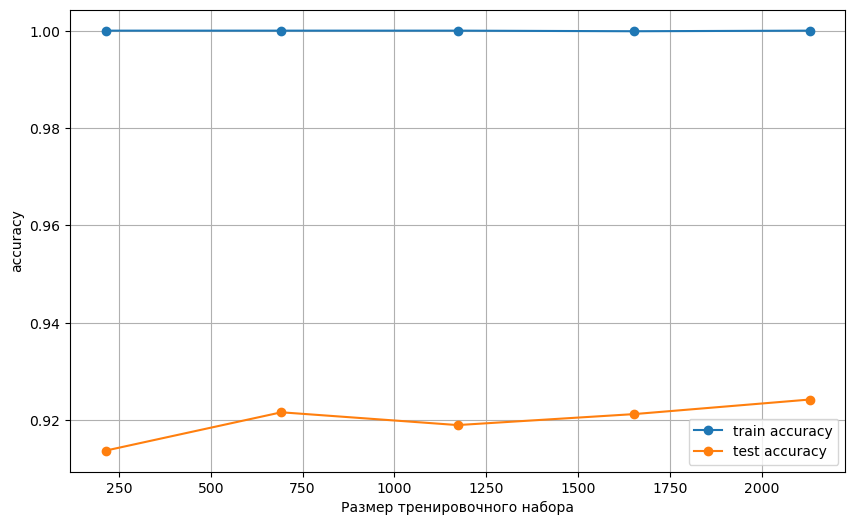

In [29]:
plot_learning_curve(rf, X_train, y_train, cv=KFold(n_splits=5, shuffle=True, random_state=42))

In [30]:
best_search = grid_search.best_estimator_
print(classification_report(y_test, best_search.predict(X_test)))

              precision    recall  f1-score   support

           0       0.91      0.98      0.94       570
           1       0.76      0.40      0.53        97

    accuracy                           0.90       667
   macro avg       0.84      0.69      0.73       667
weighted avg       0.89      0.90      0.88       667



accuracy = 0.9, recall = 0.4

### Градиентный бустинг (XGBoost)

In [46]:
from xgboost import XGBClassifier


params_xgb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0],
    'random_state': [42]
}

xgb = XGBClassifier()
grid_search = GridSearchCV(xgb, params_xgb, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), scoring='accuracy')
grid_search.fit(X_train, y_train)

print("Лучшие параметры:", grid_search.best_params_)
print("Лучшая точность:", grid_search.best_score_)

Лучшие параметры: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'random_state': 42, 'subsample': 0.8}
Лучшая точность: 0.9276078447906346


In [47]:
best_search = grid_search.best_estimator_
print(classification_report(y_test, best_search.predict(X_test)))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95       570
           1       0.75      0.55      0.63        97

    accuracy                           0.91       667
   macro avg       0.84      0.76      0.79       667
weighted avg       0.90      0.91      0.90       667



accuracy = 0.91, recall = 0.55

### Деревья решений

In [50]:
params_dt = {
    'max_depth': [3, 5, 7],
    'min_samples_leaf': [1, 2, 5],
    'criterion': ['gini', 'entropy'],
    'random_state': [42]
}

dt = DecisionTreeClassifier()
grid_search = GridSearchCV(dt, params_dt, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), scoring='accuracy')
grid_search.fit(X_train, y_train)

print("Лучшие параметры:", grid_search.best_params_)

Лучшие параметры: {'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 5, 'random_state': 42}


In [51]:
best_search = grid_search.best_estimator_
print(classification_report(y_test, best_search.predict(X_test)))

              precision    recall  f1-score   support

           0       0.91      0.96      0.93       570
           1       0.65      0.41      0.50        97

    accuracy                           0.88       667
   macro avg       0.78      0.69      0.72       667
weighted avg       0.87      0.88      0.87       667



accuracy = 0.88, recall = 0.41

### Наивный Байес

In [52]:
params_nb = {
    'var_smoothing': [1e-9, 1e-8, 1e-7]
}

nb = GaussianNB()
grid_search = GridSearchCV(nb, params_nb, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), scoring='accuracy')
grid_search.fit(X_train, y_train)

print("Лучший var_smoothing:", grid_search.best_params_)

Лучший var_smoothing: {'var_smoothing': 1e-09}


In [53]:
best_search = grid_search.best_estimator_
print(classification_report(y_test, best_search.predict(X_test)))

              precision    recall  f1-score   support

           0       0.90      0.92      0.91       570
           1       0.47      0.41      0.44        97

    accuracy                           0.85       667
   macro avg       0.69      0.67      0.68       667
weighted avg       0.84      0.85      0.84       667



accuracy = 0.85, recall = 0.41

# Итоговое сравнение моделей

In [56]:
import pandas as pd

data = {
    'Модель': ['KNN', 'Логистическая регрессия', 'SVM', 'Random Forest', 'Градиентный бустинг', 'Деревья решений', 'Наивный Байес'],
    'Accuracy': [0.89, 0.86, 0.91, 0.9, 0.91, 0.88, 0.85],
    'Recall': [0.45, 0.18, 0.54, 0.4, 0.55, 0.41, 0.41]
}

df = pd.DataFrame(data)
df.set_index('Модель', inplace=True)

df_transposed = df.T

display(df_transposed)

Модель,KNN,Логистическая регрессия,SVM,Random Forest,Градиентный бустинг,Деревья решений,Наивный Байес
Accuracy,0.89,0.86,0.91,0.9,0.91,0.88,0.85
Recall,0.45,0.18,0.54,0.4,0.55,0.41,0.41


Лучшие предсказания дали SVM и градиентный бустинг